In [1]:
import nibabel as nib
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Functions

In [2]:
def load_images(index):
    t1_data = nib.load(f'{index}/T1.nii').get_fdata()
    t2_data = nib.load(f'{index}/T2_FLAIR.nii').get_fdata()
    gt_data = nib.load(f'{index}/LabelsForTesting.nii').get_fdata()
    return t1_data, t2_data, gt_data

def kmeans_and_covariance(input_data, num_classes):
    """Initialize means and variances using KMeans clustering.
    
    Args:
        input_data (np.ndarray): Input data of shape (N, M)
        num_classes (int): Number of clusters
    
    Returns:
        tuple: (means, variances) arrays of shape (num_classes, M)
    """
    # Fit KMeans
    kmeans = KMeans(n_clusters=num_classes, random_state=42).fit(input_data)
    
    # Initialize arrays to store means and covariances
    means = np.zeros((num_classes, input_data.shape[1]))
    covariances = np.zeros((num_classes, input_data.shape[1], input_data.shape[1]))
    
    # Calculate means and covariances for each class
    for k in range(num_classes):
        class_data = input_data[kmeans.labels_ == k]
        means[k] = np.mean(class_data, axis=0)
        covariances[k] = np.cov(class_data, rowvar=False)
    
    return means, covariances

def gaussian(x, mean, cov):
    size = len(mean)
    
    # Calculate the determinant and inverse of the covariance matrix
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)

    # Calculate the normalization constant
    norm_const = 1.0 / (np.power((2 * np.pi), size / 2) * np.sqrt(det_cov))

    # Calculate the exponent part
    x_mu = x - mean
    exponent = -0.5 * np.sum(x_mu @ inv_cov * x_mu, axis=1)
    
    # Combine the normalization constant with the exponent
    return norm_const * np.exp(exponent)

def e_step(data, means, covariances, mixing_coeffs):
    """Perform E-step of EM algorithm.
    
    Args:
        data: Input data array of shape (N, D)
        means: Array of means for each cluster
        covariances: Array of covariance matrices
        mixing_coeffs: Array of mixing coefficients
    
    Returns:
        tuple: (weights, total_weights) - Normalized responsibilities and their sum
    """
    weights = []
    for mean, cov, pi in zip(means, covariances, mixing_coeffs):
        weights.append(pi * gaussian(data, mean, cov))
    
    weights = np.array(weights)
    total_weight = np.sum(weights, axis=0)
    weights /= total_weight[np.newaxis, :]
    
    return weights, total_weight

def m_step(data, weights):
    """Perform M-step of EM algorithm.
    
    Args:
        data: Input data array of shape (N, D)
        weights: Responsibilities from E-step
    
    Returns:
        tuple: (means, covariances, mixing_coeffs) - Updated parameters
    """
    n_clusters = len(weights)
    means = []
    covariances = []
    mixing_coeffs = []
    
    for k in range(n_clusters):
        # Update means
        mean_k = np.sum(weights[k][:, np.newaxis] * data, axis=0) / np.sum(weights[k])
        means.append(mean_k)
        
        # Update covariances
        cov_k = np.cov(data.T, aweights=weights[k], bias=True)
        covariances.append(cov_k)
        
        # Update mixing coefficients
        mixing_coeffs.append(np.mean(weights[k]))
    
    return np.array(means), np.array(covariances), np.array(mixing_coeffs)

def expectation_maximization(data, n_clusters, max_iter=100, tol=1e-4):
    """Perform EM algorithm for Gaussian Mixture Model.
    
    Args:
        data: Input data array of shape (N, D)
        n_clusters: Number of clusters
        max_iter: Maximum number of iterations
        tol: Convergence tolerance
        
    Returns:
        tuple: (predictions, means, covariances, mixing_coeffs)
    """
    # Initialize parameters using KMeans
    means, covariances = kmeans_and_covariance(data, n_clusters)
    mixing_coeffs = np.ones(n_clusters) / n_clusters
    
    log_likelihood = 0
    log_likelihood_list = []
    
    for _ in range(max_iter):
        # E-step
        weights, total_weight = e_step(data, means, covariances, mixing_coeffs)
        
        # M-step
        means, covariances, mixing_coeffs = m_step(data, weights)
        
        # Check convergence
        new_log_likelihood = np.sum(np.log(total_weight))
        log_likelihood_list.append(new_log_likelihood)
        
        if np.abs(new_log_likelihood - log_likelihood) < tol:
            break
            
        log_likelihood = new_log_likelihood
    
    return means, covariances, mixing_coeffs

def dice_coefficient(segmented_image: np.ndarray, gt_labels: np.ndarray, label: int) -> float:
    """Calculate Dice coefficient for a specific label.
    
    Args:
        segmented_image (np.ndarray): Predicted segmentation
        gt_labels (np.ndarray): Ground truth labels
        label (int): Label to calculate Dice coefficient for
        
    Returns:
        float: Dice coefficient value between 0 and 1
    """
    seg_mask = segmented_image == label
    gt_mask = gt_labels == label
    
    intersection = np.sum(seg_mask & gt_mask)
    denominator = np.sum(seg_mask) + np.sum(gt_mask)
    
    return (2.0 * intersection) / denominator if denominator > 0 else 0.0

def show_results(image, gt, prediction, modality='T1', i=0):
    csf, gm, wm = dice_coefficient(prediction, gt, 1), dice_coefficient(prediction, gt, 2), dice_coefficient(prediction, gt, 3)
    print(f'Dice Score: CSF: {csf}, GM: {gm}, WM: {wm}, Avg: {(csf+gm+wm)/3}')

    slice_idx = prediction.shape[2] // 2
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(image[:, :, slice_idx], cmap='gray')
    plt.title(f'Original Image Slice for {modality} image {i+1}')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(gt[:, :, slice_idx], cmap='gray')
    plt.title('Ground Truth Slice')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(prediction[:, :, slice_idx], cmap='gray')
    plt.title('Segmented Image Slice')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
def prediction(data, means, covariances, mixing_coeffs, original_image, gt_labels):
    segmented_image = np.zeros_like(original_image, dtype=int)
    weights = []
    
    # Calculate weights for each class
    for mean, cov, pi in zip(means, covariances, mixing_coeffs):
        weights.append(pi * gaussian(data, mean, cov))
    
    # Get class assignments (0-based indices)
    class_assignments = np.argmax(np.column_stack(weights), axis=1)
    
    # Create mapping based on mean intensities (average of both modalities)
    mean_intensities = np.mean(means, axis=1)  # Average across modalities
    sorted_indices = np.argsort(mean_intensities)  # Sort from lowest to highest
    
    # Create mapping dictionary: original_index -> new_label(1-based)
    label_mapping = {old_idx: new_label + 1 
                    for new_label, old_idx in enumerate(sorted_indices)}
    
    # Apply mapping to class assignments
    remapped_assignments = np.vectorize(label_mapping.get)(class_assignments)
    
    # Assign labels only where gt_labels > 0
    segmented_image[gt_labels > 0] = remapped_assignments
    
    return segmented_image

# Multi modality

Dice Score: CSF: 0.9066640139628682, GM: 0.8219036845044606, WM: 0.8496653199059278, Avg: 0.8594110061244189


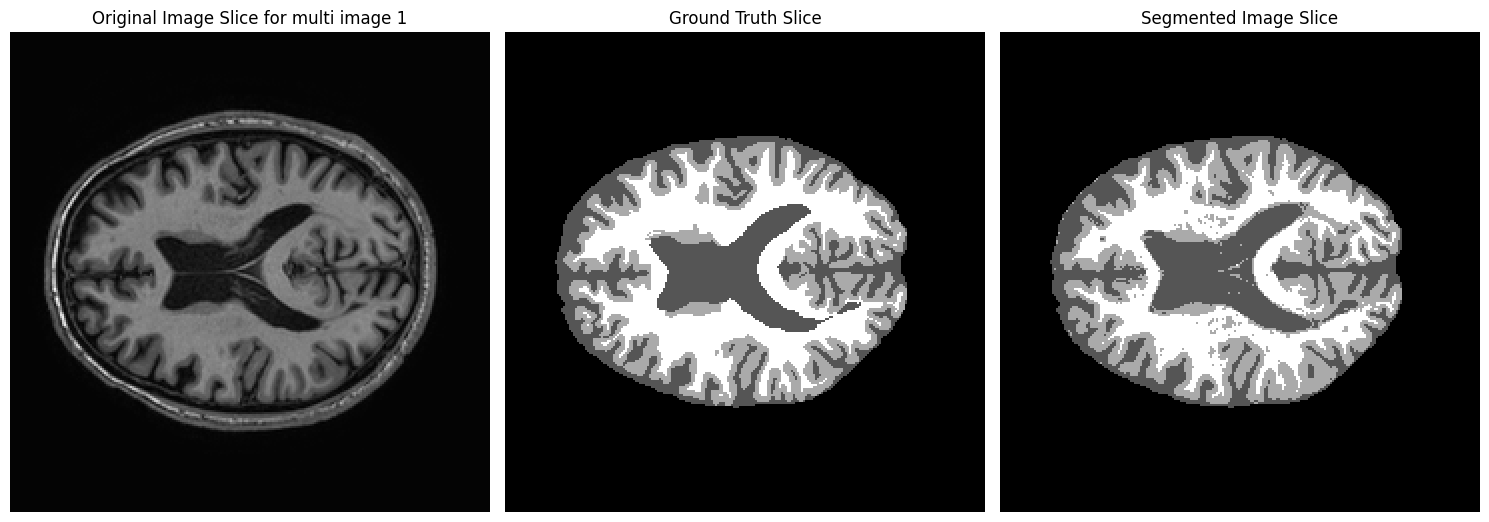

Dice Score: CSF: 0.8417022804316457, GM: 0.188726013632974, WM: 0.5286978419782449, Avg: 0.5197087120142881


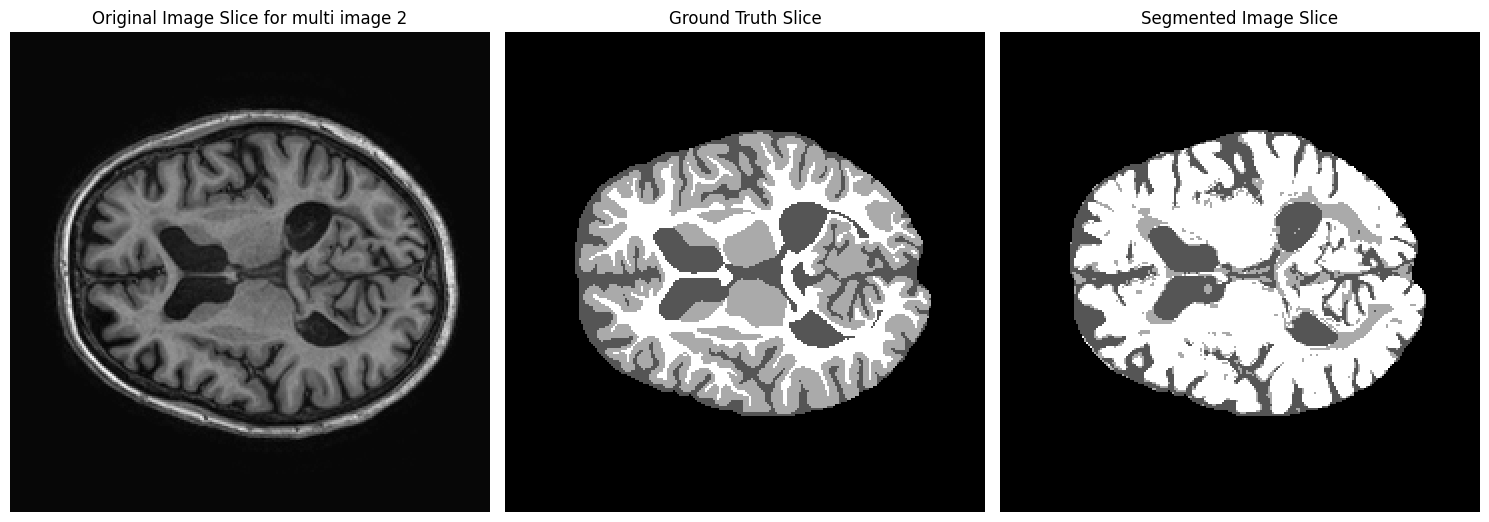

Dice Score: CSF: 0.8549397620390246, GM: 0.778606784981287, WM: 0.8374335146784196, Avg: 0.8236600205662438


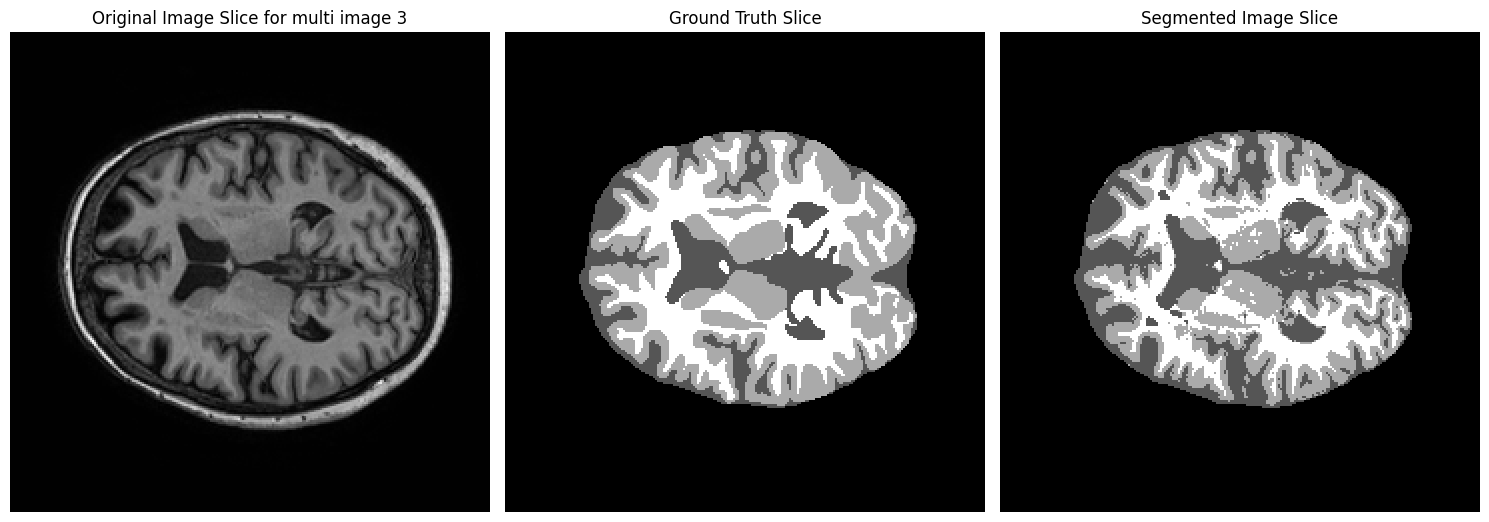

Dice Score: CSF: 0.9008121628646463, GM: 0.8398889923141875, WM: 0.8686291887230831, Avg: 0.8697767813006391


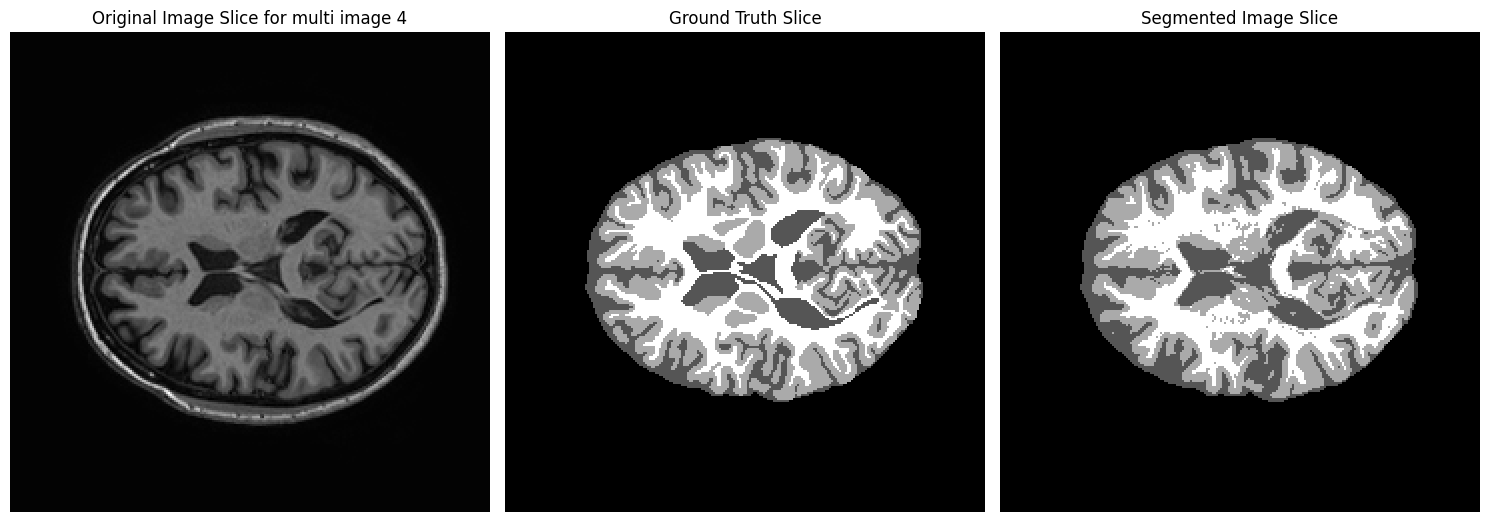

Dice Score: CSF: 0.8658901689464386, GM: 0.8464093015252633, WM: 0.889003527125273, Avg: 0.8671009991989916


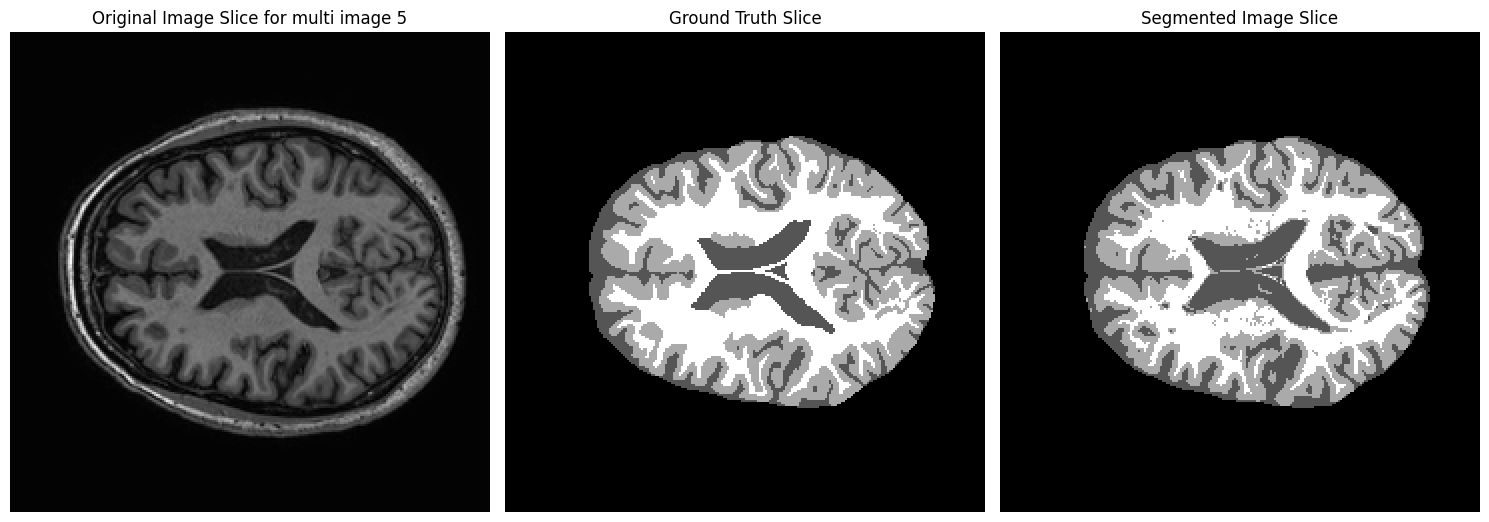

In [3]:
modality = 'multi'
for i in range(5):
    t1_image, t2_image, gt = load_images(i+1)
    input_data  = [np.stack((t1[gt > 0], t2[gt > 0]), axis=1) for t1, t2, gt in zip(t1_image, t2_image, gt)]
    input_data = np.concatenate(input_data, axis=0)
    means, variances, mixing_coeffs = expectation_maximization(input_data, 3)
    segmented_data = prediction(input_data, means, variances, mixing_coeffs, t1_image, gt)
    show_results(t1_image, gt, segmented_data, modality='multi', i=i)